In [1]:
#Compare preprocessing methods for mammography images.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import cv2


DICOM_BASE = Path(
    "/mnt/cafetera/mammo/vindr/images"
)

CSV_PATH = Path(
    "/home/enric_sena/Desktop/prova_enric/vindr_dataset/finding_annotations.csv"
)

IMG_SIZE = 1024

In [2]:
def load_dicom(dicom_path):
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    return ds, img


def preprocess_clipping(img):
    p1, p99 = np.percentile(img, [1, 99])

    out = np.clip(
        (img - p1) / (p99 - p1 + 1e-6),
        0,
        1,
    )

    return (out * 255).astype(np.uint8)


def get_first_value(value):
    """
    DICOM puede devolver WindowCenter/Width como
    número simple o MultiValue.
    """
    if isinstance(value, (list, tuple)):
        return float(value[0])

    try:
        return float(value[0])
    except (TypeError, IndexError):
        return float(value)


def preprocess_windowing(ds, img):

    # --------------------------------------------------------
    # Intentamos usar VOI LUT si existe
    # --------------------------------------------------------

    if "VOILUTSequence" in ds:

        try:
            from pydicom.pixels import apply_voi_lut

            out = apply_voi_lut(
                img,
                ds,
            ).astype(np.float32)

            out_min = out.min()
            out_max = out.max()

            out = (
                (out - out_min)
                / (out_max - out_min + 1e-6)
            )

            return (out * 255).astype(np.uint8)

        except Exception:
            pass

    # --------------------------------------------------------
    # Window Center / Width
    # --------------------------------------------------------

    if (
        "WindowCenter" in ds
        and "WindowWidth" in ds
    ):

        wc = get_first_value(ds.WindowCenter)
        ww = get_first_value(ds.WindowWidth)

        lower = wc - ww / 2
        upper = wc + ww / 2

        out = np.clip(
            (img - lower) / (upper - lower + 1e-6),
            0,
            1,
        )

        return (out * 255).astype(np.uint8)

    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    print("WARNING: DICOM sin VOI LUT / Windowing")

    return preprocess_clipping(img)


def resize_for_yolo(img):

    h, w = img.shape[:2]

    scale = min(
        IMG_SIZE / w,
        IMG_SIZE / h,
    )

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR,
    )

    return resized, scale

In [3]:
df = pd.read_csv(CSV_PATH)

df_test = df[df["split"] == "test"].copy()

image_id = df_test.iloc[0]["image_id"]
study_id = df_test.iloc[0]["study_id"]

dicom_path = (
    DICOM_BASE
    / str(study_id)
    / f"{image_id}.dicom"
)

print("Study:", study_id)
print("Image:", image_id)
print("DICOM:", dicom_path)

Study: 5683854eafabc34f6d854000d2ac6c2d
Image: 2f944efb1cb9579442df2d7fe6a579b7
DICOM: /mnt/cafetera/mammo/vindr/images/5683854eafabc34f6d854000d2ac6c2d/2f944efb1cb9579442df2d7fe6a579b7.dicom


In [4]:
ds, original = load_dicom(dicom_path)

print("Shape:", original.shape)
print("dtype:", original.dtype)
print("Photometric:", ds.PhotometricInterpretation)

print(
    "Window Center:",
    getattr(ds, "WindowCenter", "NO")
)

print(
    "Window Width:",
    getattr(ds, "WindowWidth", "NO")
)

print(
    "VOI LUT:",
    "VOILUTSequence" in ds
)

Shape: (3518, 2800)
dtype: float32
Photometric: MONOCHROME2
Window Center: 1654
Window Width: 1500
VOI LUT: True


In [5]:
clipping = preprocess_clipping(original)

windowing = preprocess_windowing(
    ds,
    original,
)

clipping_resized, _ = resize_for_yolo(clipping)
windowing_resized, _ = resize_for_yolo(windowing)

/home/enric_sena/Desktop/Mammo/.venv/lib/python3.10/site-packages/pydicom/pixels/processing.py:629: UserWarning: Applying a VOI LUT on a float input array may give incorrect results
  warn_and_log(


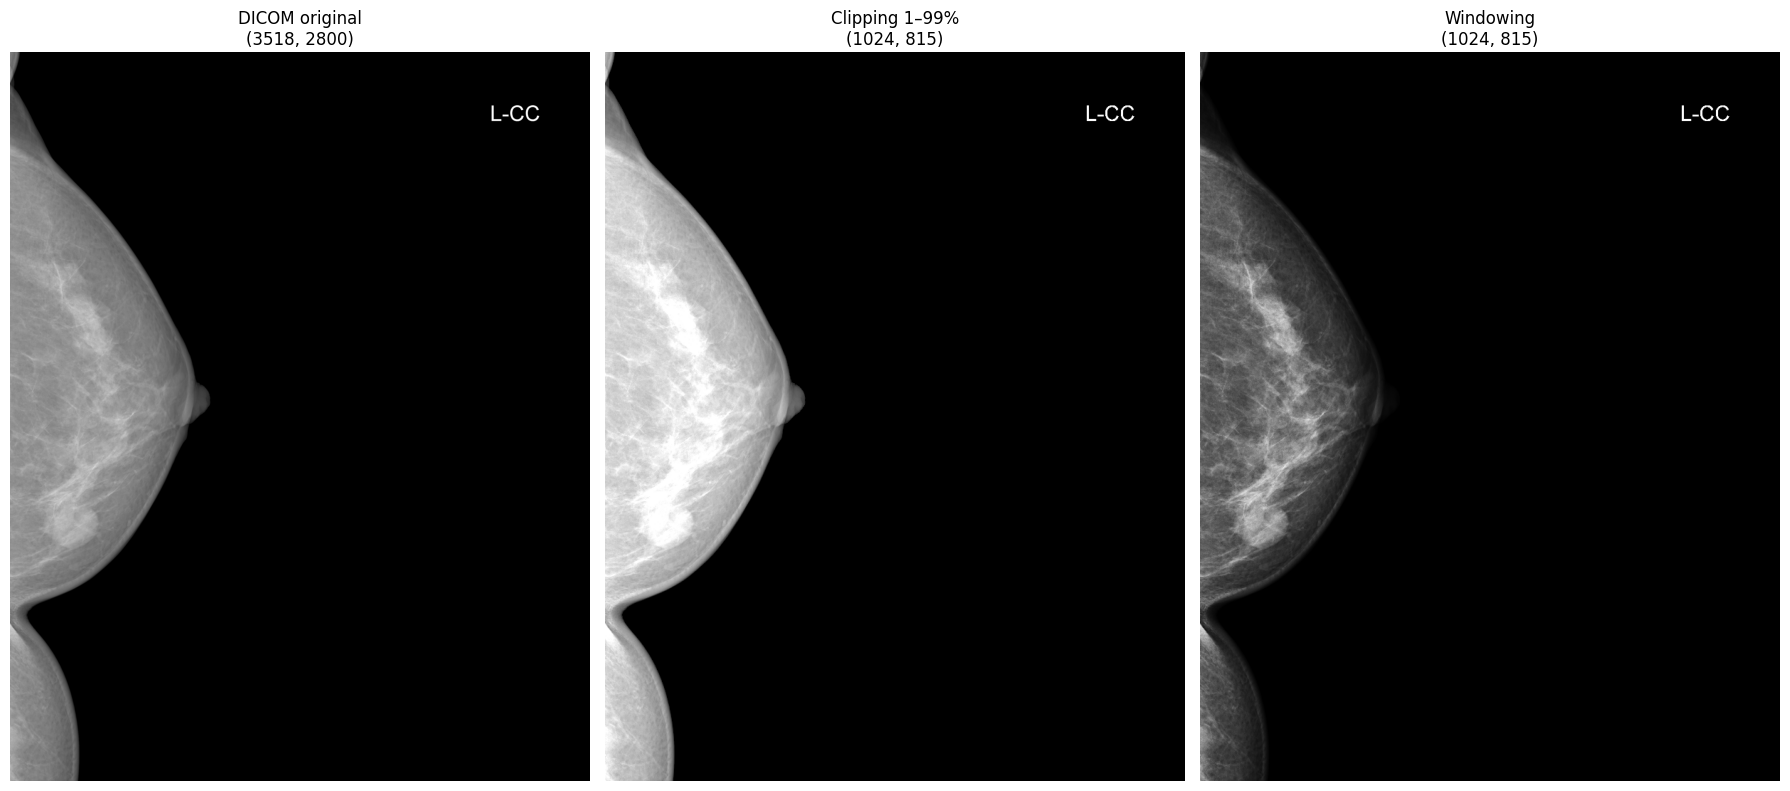

In [6]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 8),
)

axes[0].imshow(original, cmap="gray")
axes[0].set_title(
    f"DICOM original\n{original.shape}"
)

axes[1].imshow(
    clipping_resized,
    cmap="gray",
)
axes[1].set_title(
    f"Clipping 1–99%\n{clipping_resized.shape}"
)

axes[2].imshow(
    windowing_resized,
    cmap="gray",
)
axes[2].set_title(
    f"Windowing\n{windowing_resized.shape}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

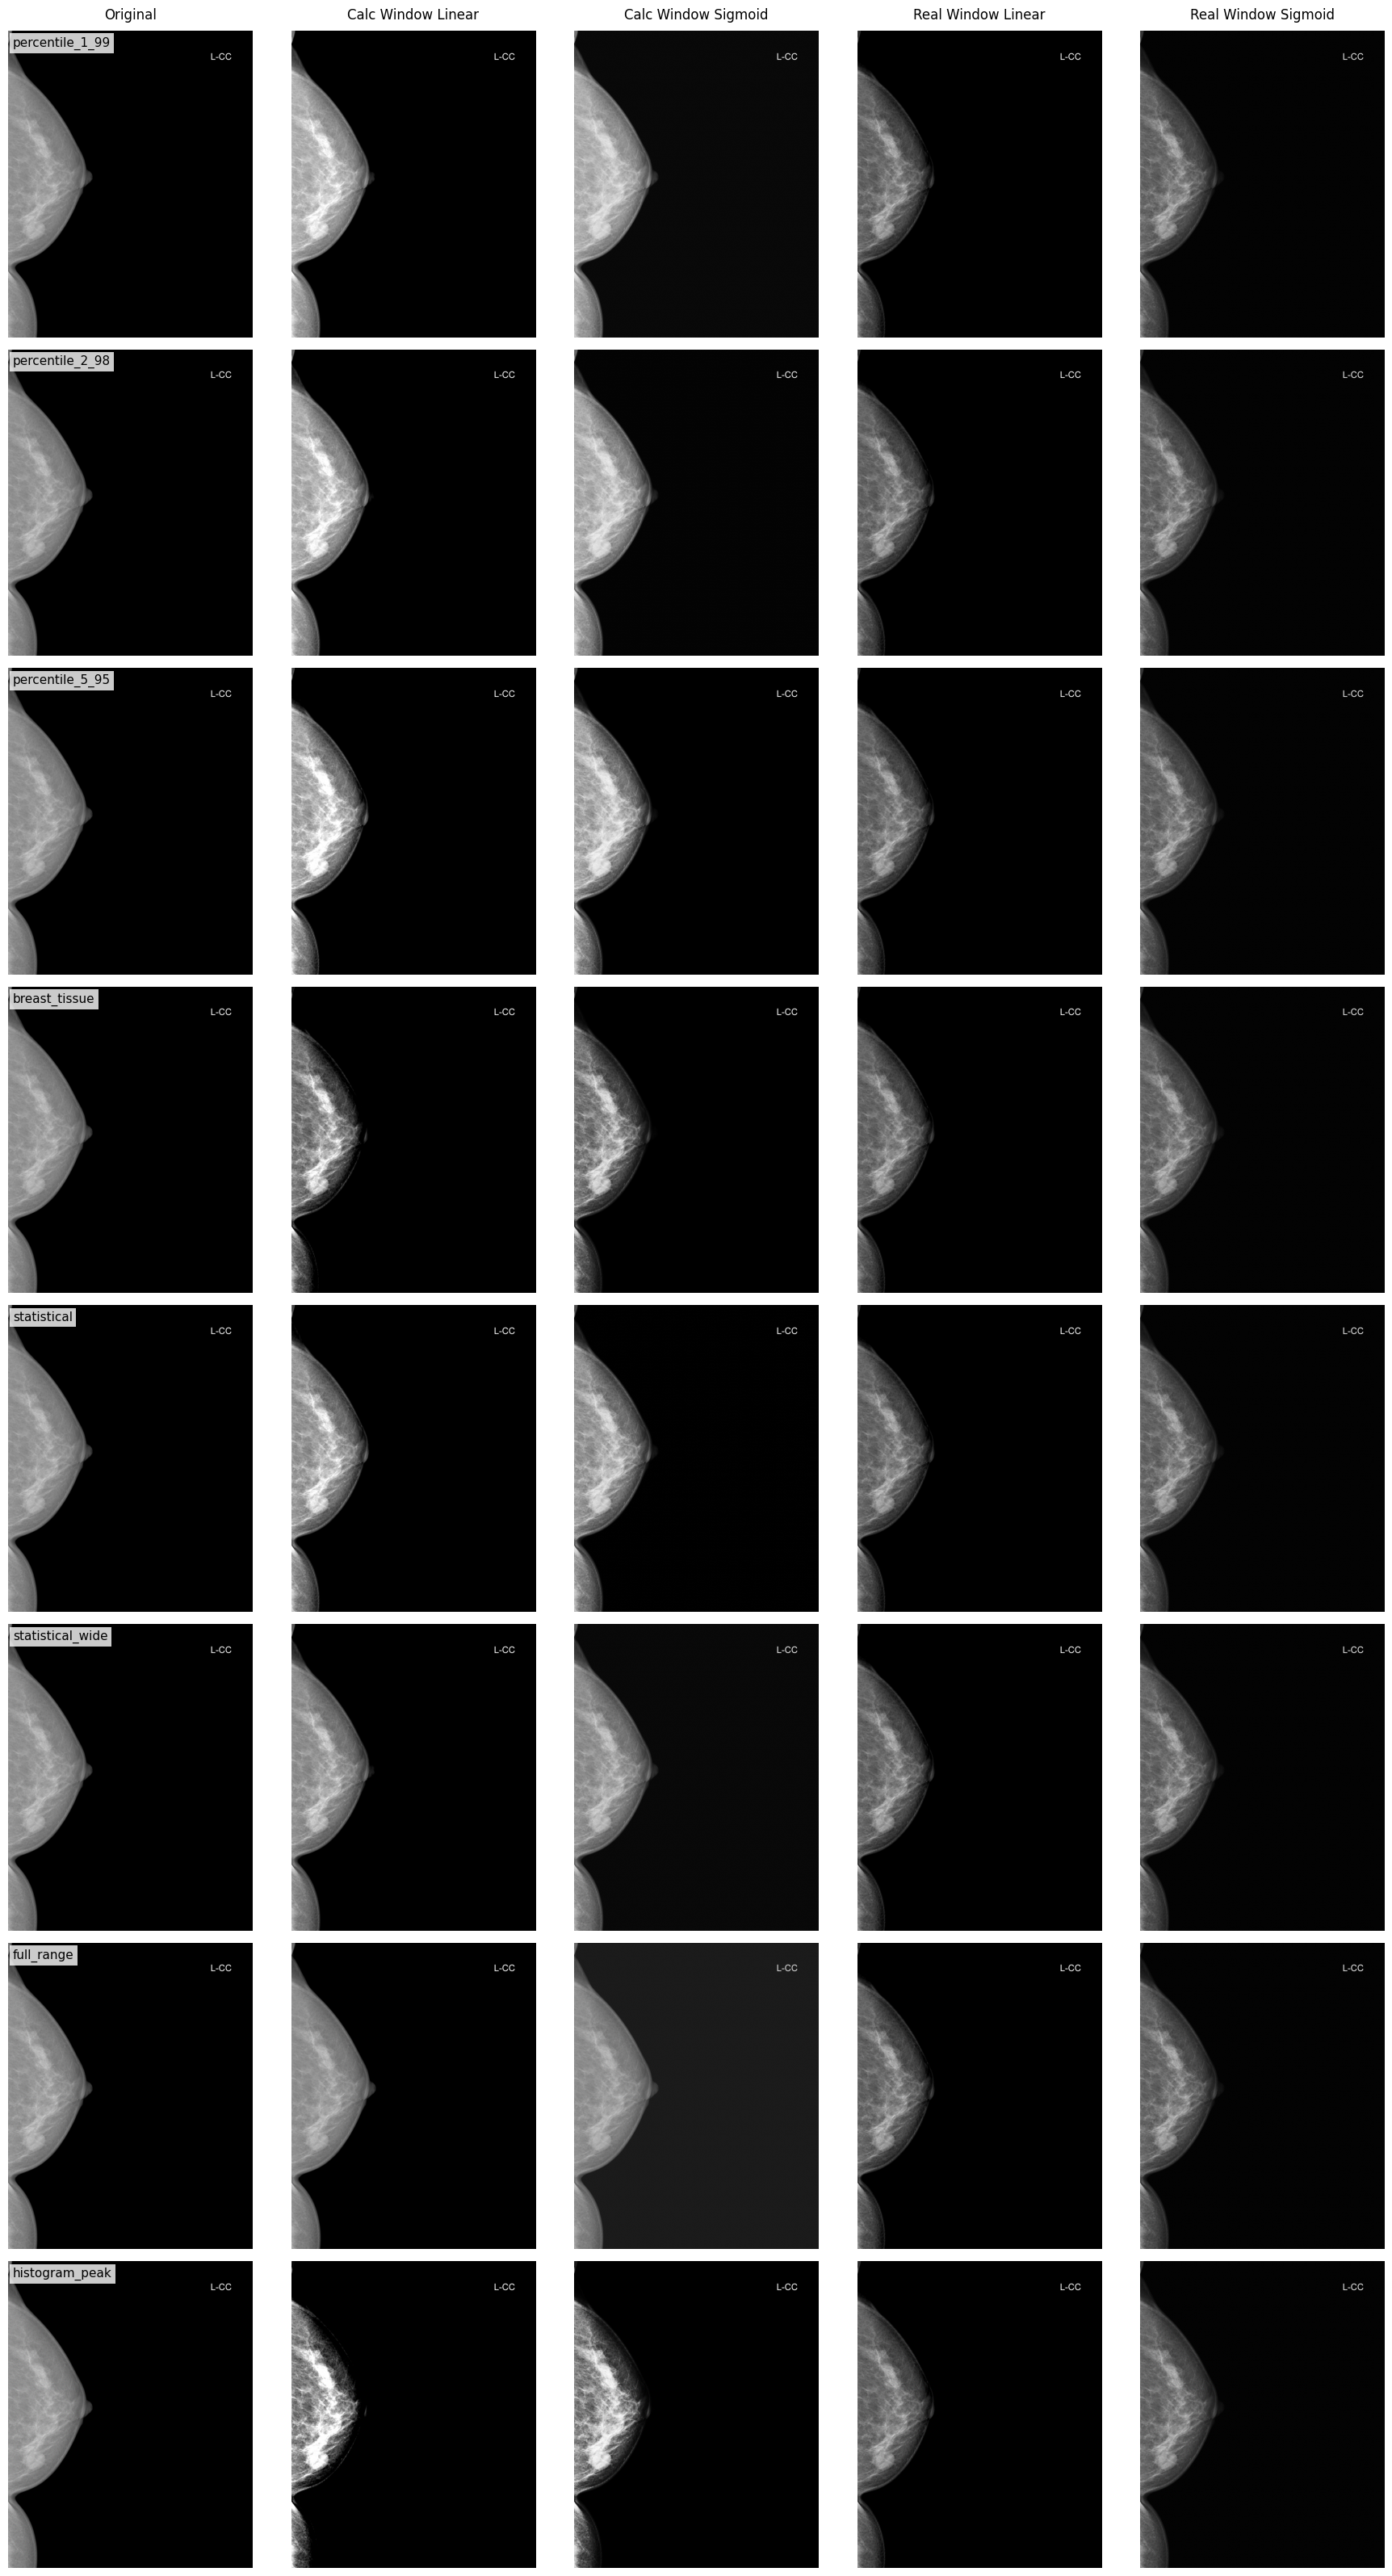

In [15]:
import matplotlib.pyplot as plt
from mammo_prep.windowing import (
    calculate_windowing,
    get_dicom_voi_lut_params,
    apply_windowing,
)

import matplotlib.pyplot as plt

methods = [
    "percentile_1_99",
    "percentile_2_98",
    "percentile_5_95",
    "breast_tissue",
    "statistical",
    "statistical_wide",
    "full_range",
    "histogram_peak",
]

dicom_params = get_dicom_voi_lut_params(ds)

wc_dicom = dicom_params["window_center"]
ww_dicom = dicom_params["window_width"]

fig, axes = plt.subplots(
    len(methods),
    5,
    figsize=(18, 4 * len(methods))
)

column_titles = [
    "Original",
    "Calc Window Linear",
    "Calc Window Sigmoid",
    "Real Window Linear",
    "Real Window Sigmoid",
]

for i, method in enumerate(methods):

    wc, ww = calculate_windowing(
        img,
        method=method,
        exclude_background=True,
    )

    calc_linear = apply_windowing(
        img,
        window_center=wc,
        window_width=ww,
        voi_func="LINEAR",
    )

    calc_sigmoid = apply_windowing(
        img,
        window_center=wc,
        window_width=ww,
        voi_func="SIGMOID",
    )

    real_linear = apply_windowing(
        img,
        window_center=wc_dicom,
        window_width=ww_dicom,
        voi_func="LINEAR",
    )

    real_sigmoid = apply_windowing(
        img,
        window_center=wc_dicom,
        window_width=ww_dicom,
        voi_func="SIGMOID",
    )

    images = [
        img,
        calc_linear,
        calc_sigmoid,
        real_linear,
        real_sigmoid,
    ]

    for j, image in enumerate(images):

        axes[i, j].imshow(
            image,
            cmap="gray",
            vmin=0 if j > 0 else None,
            vmax=255 if j > 0 else None,
        )

        axes[i, j].axis("off")

        if i == 0:
            axes[i, j].set_title(
                column_titles[j],
                fontsize=12,
                pad=10,
            )

    # Nom del mètode dins de la primera imatge de cada fila
    axes[i, 0].text(
        0.02,
        0.98,
        method,
        transform=axes[i, 0].transAxes,
        fontsize=11,
        verticalalignment="top",
        horizontalalignment="left",
        bbox=dict(
            facecolor="white",
            alpha=0.8,
            edgecolor="none",
            pad=3,
        ),
    )

plt.tight_layout()
plt.show()
